Trying out Shap : First Iteration Model


In [3]:
import xgboost 
import pickle
import pandas as pd
# import matplotlib
import matplotlib.pyplot as plt

# # Load the model
# with open('xgb_model.pkl', 'rb') as f:
#     model = pickle.load(f)
    
# with open("gridxgb_model.pkl", "wb") as f:
#     model2 = pickle.load(f)
    
# with open("rf_model.pkl", "wb") as f:
#     model2 = pickle.load(f)

In [4]:
import shap

# Create explainer for tree-based models
# explainer = shap.TreeExplainer(model)
# explainer_rf = shap.TreeExplainer(model2)

In [5]:
# Calculate SHAP values for test set
# test_df = pd.read_csv('test.csv')
# X_test = test_df.drop(columns=["TenYearCHD", "stratify"])
# shap_values = explainer.shap_values(X_test)
# # shap_values_rf = explainer_rf.shap_values(X_test)

# # Get expected value (baseline)
# expected_value = explainer.expected_value
# # expected_value_rf = explainer_rf.expected_value 

In [6]:
# Summary plot (global feature importance)
# shap.summary_plot(shap_values, X_test)

# # Beeswarm plot (more detailed)
# shap.summary_plot(shap_values, X_test, plot_type="dot")

# Waterfall plot for single patient (first test patient)
# male_patient = X_test.iloc[70]
# female_patient = male_patient.copy()

# female_patient['male'] = 0

# created_pair = pd.DataFrame([male_patient, female_patient])
# print(male_patient)
# shap_values_pair = explainer.shap_values(created_pair)



# shap.waterfall_plot(shap.Explanation(
#     values=shap_values_pair[0],
#     base_values=expected_value,
#     data=created_pair.iloc[0],
#     feature_names=X_test.columns.tolist()
# ))

# shap.waterfall_plot(shap.Explanation(
#     values=shap_values_pair[1],
#     base_values=expected_value,
#     data=created_pair.iloc[1],
#     feature_names=X_test.columns.tolist()
# ))

# shap.waterfall_plot(shap.Explanation(
#     values=shap_values_rf[28],
#     base_values=expected_value_rf,
#     data=X_test.iloc[28],
#     feature_names=X_test.columns.tolist()
# ))

# shap.waterfall_plot(shap.Explanation(
#     values=shap_values[100],
#     base_values=expected_value,
#     data=X_test.iloc[100],
#     feature_names=X_test.columns.tolist()
# ))

In [7]:
#  SHAP on the cardio_dataset trained baseline model
with open("models/baseline_models/cardio_xgb_baseline_model.pkl", 'rb') as f:
    model_baseline = pickle.load(f)

explainer_baseline = shap.TreeExplainer(model_baseline)

In [23]:
# Calculate SHAP values for test set
test_df_baseline = pd.read_csv('data/test_train_val_sets/cardio_baseline_test.csv')
y_test_baseline = test_df_baseline["cardio"]

X_test_baseline = test_df_baseline.drop(columns=["cardio", "stratify"])
shap_values_baseline = explainer_baseline.shap_values(X_test_baseline)
# shap_values_rf = explainer_rf.shap_values(X_test)

# Get expected value (baseline)
expected_value = explainer_baseline.expected_value

# expected_value_rf = explainer_rf.expected_value 

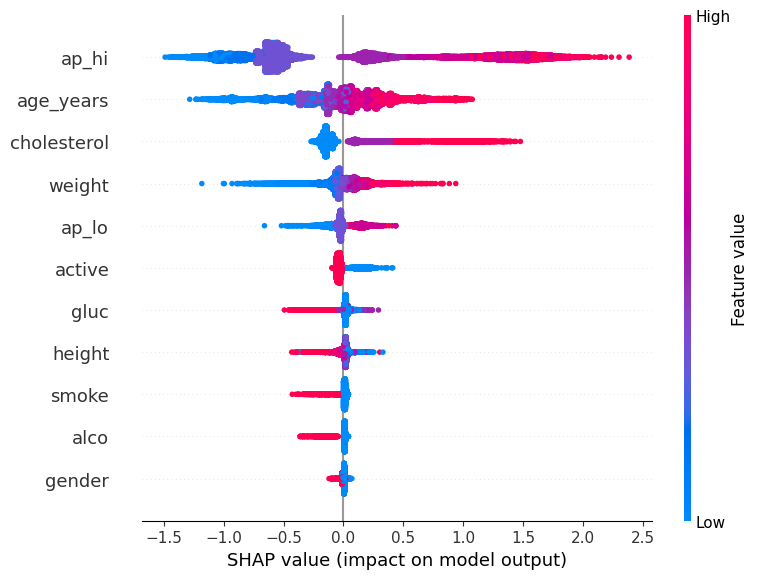

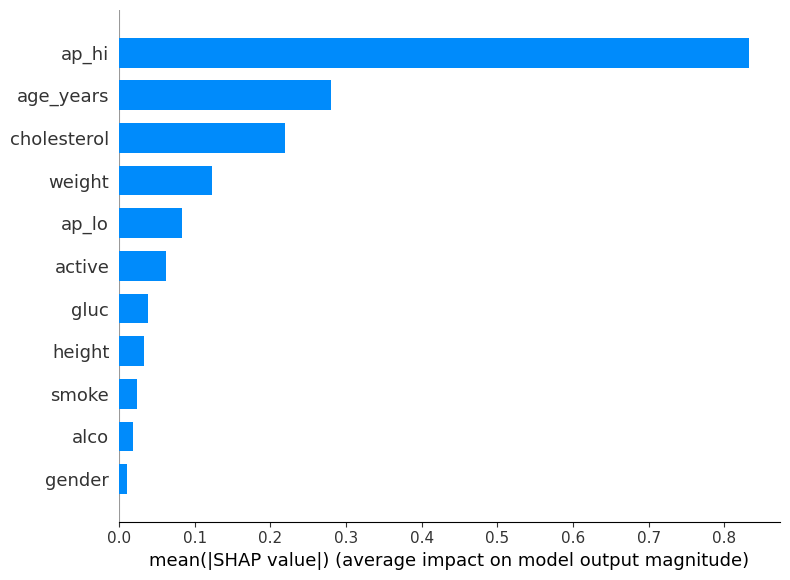

In [9]:
shap.summary_plot(shap_values_baseline, X_test_baseline, plot_type="dot")
shap.summary_plot(shap_values_baseline, X_test_baseline, plot_type="bar")



# Sex-Stratified SHAP now

In [10]:
X_test_female = X_test_baseline[X_test_baseline['gender'] == 0]
X_test_male   = X_test_baseline[X_test_baseline['gender'] == 1]

shap_values_female = explainer_baseline.shap_values(X_test_female)
shap_values_male   = explainer_baseline.shap_values(X_test_male)


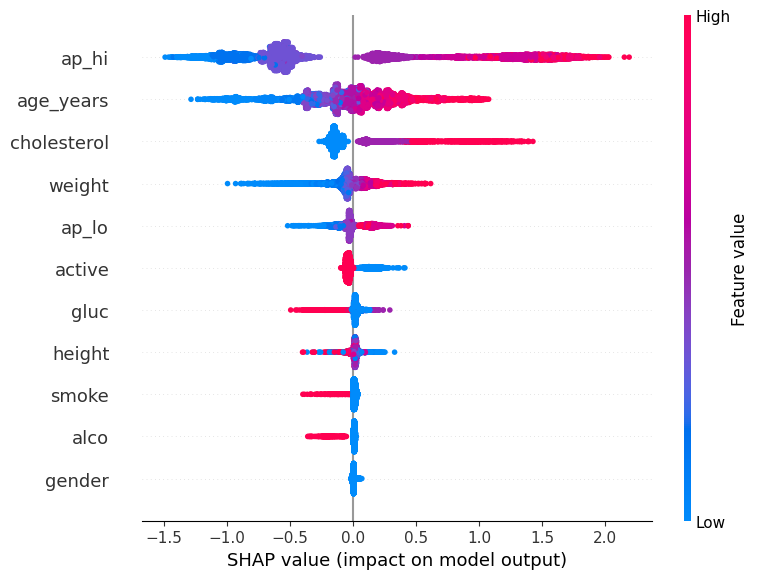

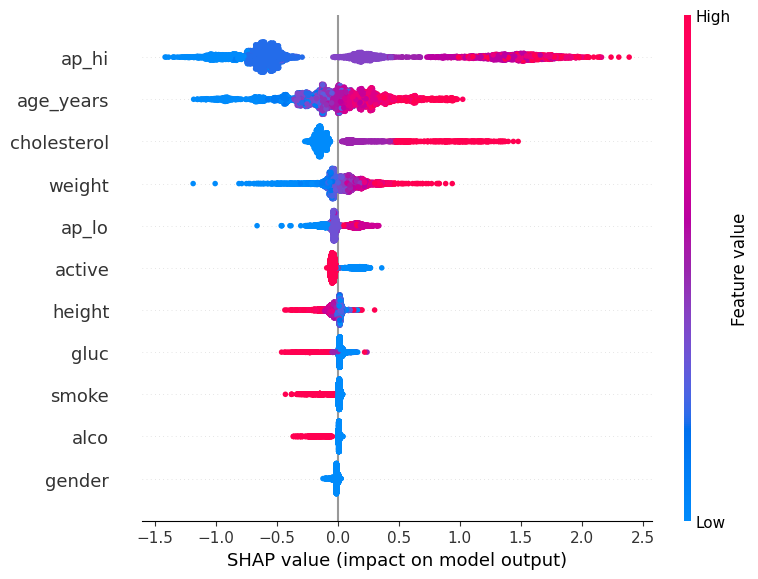

In [11]:
shap.summary_plot(shap_values_female, X_test_female, plot_type="dot")
shap.summary_plot(shap_values_male, X_test_male, plot_type="dot")

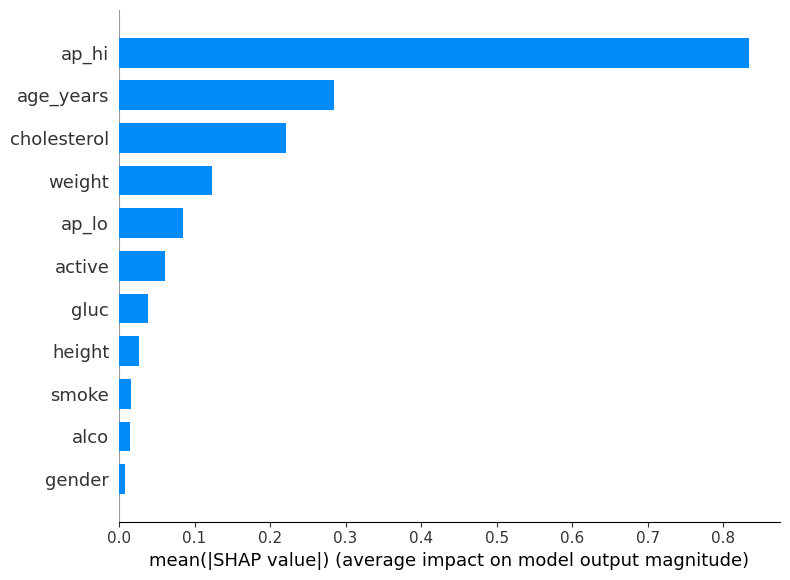

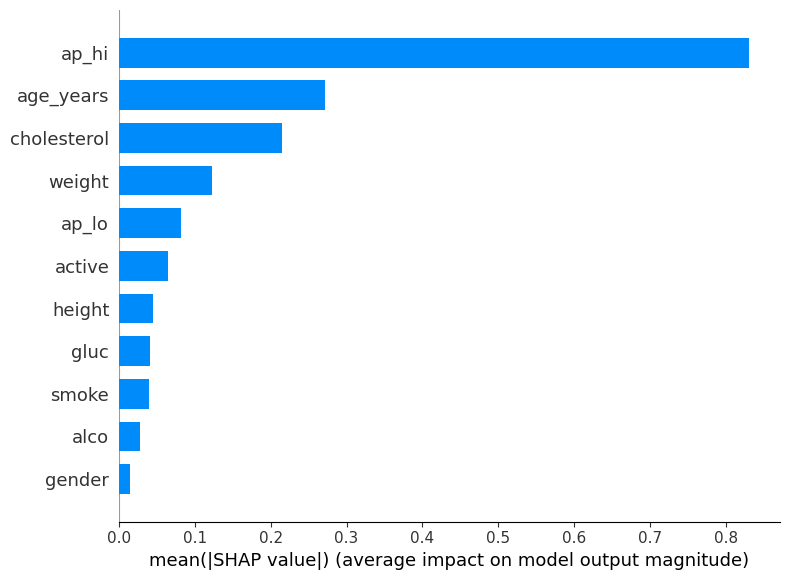

In [12]:
shap.summary_plot(shap_values_female, X_test_female, plot_type="bar")
shap.summary_plot(shap_values_male, X_test_male, plot_type="bar")

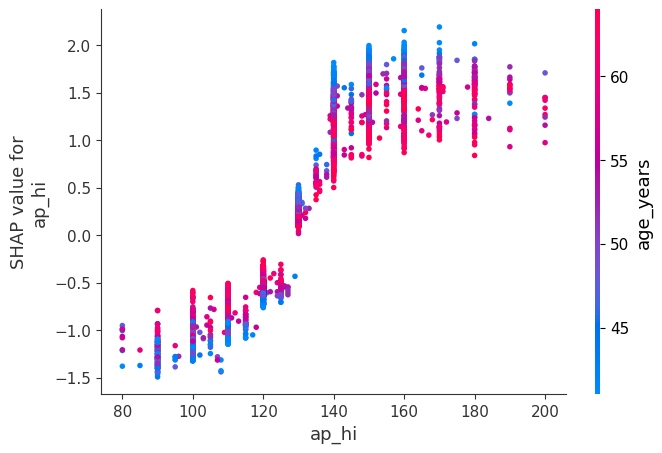

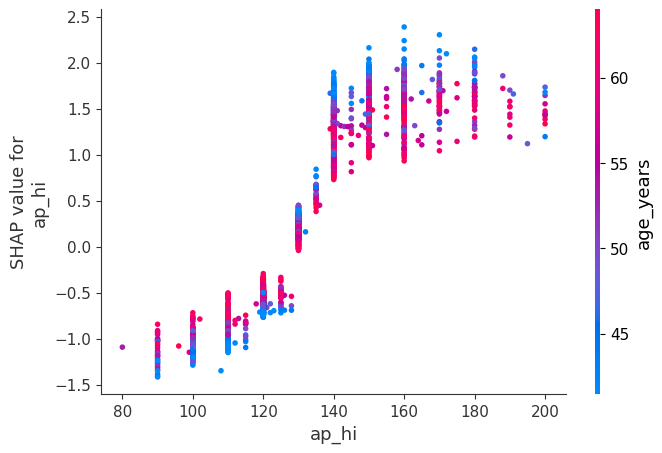

In [13]:
shap.dependence_plot("ap_hi", shap_values_female, X_test_female)
shap.dependence_plot("ap_hi", shap_values_male, X_test_male)

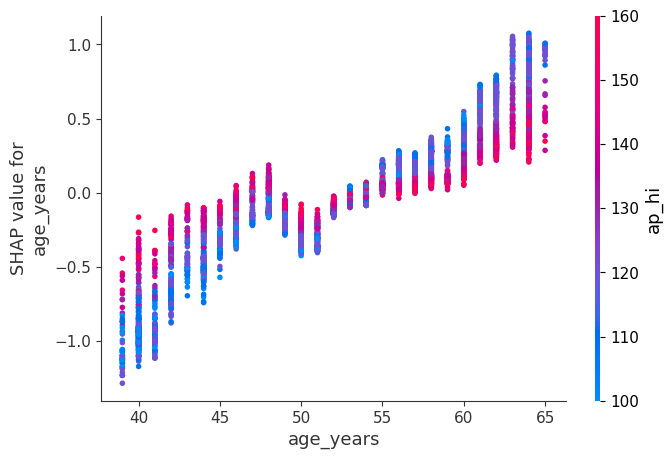

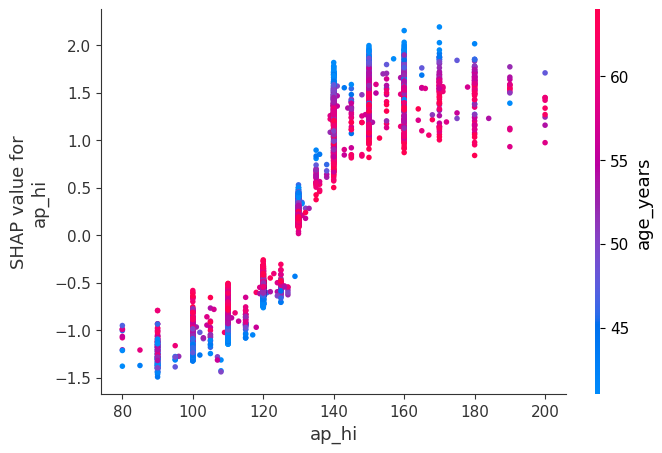

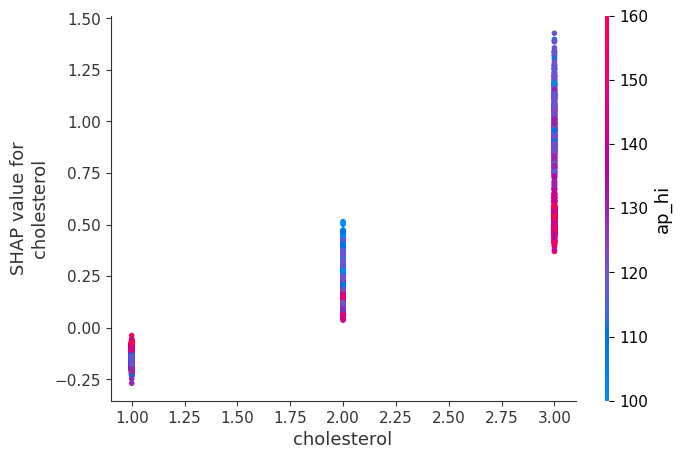

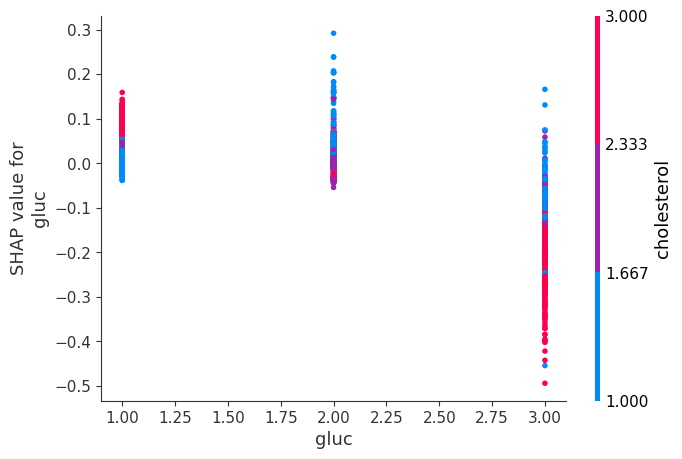

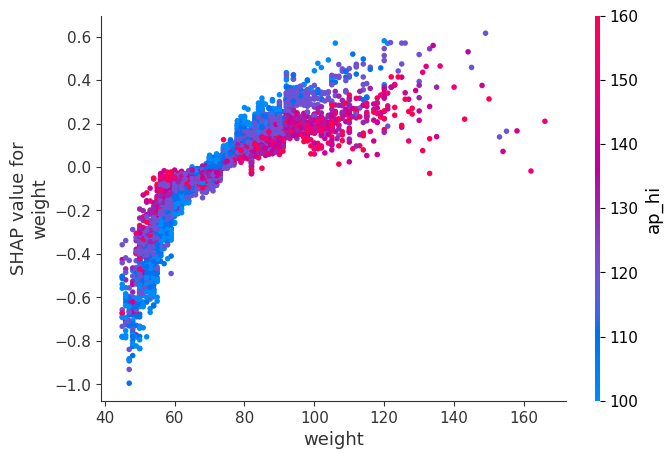

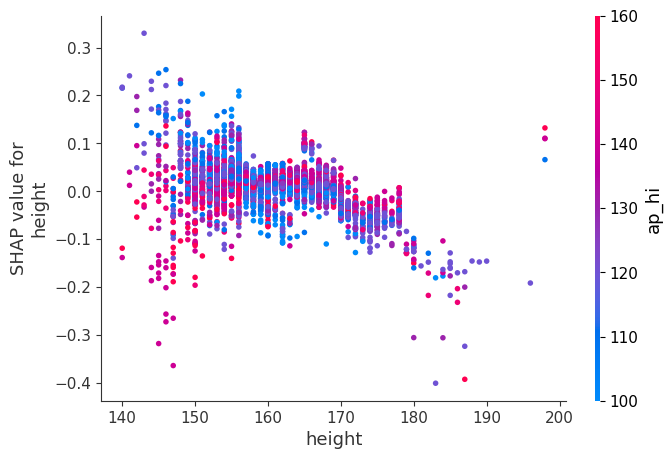

In [14]:
features = ["age_years", "ap_hi", "cholesterol", "gluc", "weight", "height"]

for f in features:
    shap.dependence_plot(f, shap_values_female, X_test_female)

In [24]:
import numpy as np
import pandas as pd

feature = "ap_hi"
bins = [0, 120, 130, 140, 150, 160, np.inf]
bin_labels = ["<120", "120-129", "130-139", "140-149", "150-159", "160+"]
high_risk_bins = ["140-149", "150-159", "160+"]

# ── Build female df with SHAP ─────────────────────────────────
df = X_test_female.copy().reset_index(drop=True)
feature_idx = X_test_female.columns.get_loc(feature)
df["shap_value"] = shap_values_female[:, feature_idx].astype(float)

df["feature_bin"] = pd.cut(
    df[feature], bins=bins, labels=bin_labels, right=False
)

# ── 10th percentile threshold per bin ────────────────────────
thresholds = df.groupby("feature_bin")["shap_value"].quantile(0.10).astype(float).to_dict()
df["bin_threshold"] = df["feature_bin"].astype(str).map(thresholds)

# ── Underresponse flags ───────────────────────────────────────
df["underresponse_flag"] = (
    df["shap_value"] <= df["bin_threshold"]
).astype(int)

df["underresponse_flag_highrisk"] = (
    df["feature_bin"].isin(high_risk_bins) &
    (df["shap_value"] <= df["bin_threshold"])
).astype(int)

# ── Add FN indicator ──────────────────────────────────────────
# Reset index on female mask to align with df
female_mask = test_df_baseline["gender"].values == 0

y_test_female = y_test_baseline[female_mask].reset_index(drop=True)
y_pred_female = model_baseline.predict(X_test_female)

df["true_label"] = y_test_female.values
df["predicted"]  = y_pred_female
df["is_fn"]      = ((df["true_label"] == 1) & (df["predicted"] == 0)).astype(int)

# ── Validation — does the flag capture FN women? ─────────────
flagged = df["underresponse_flag"] == 1
fn      = df["is_fn"] == 1

precision_flag = df[flagged]["is_fn"].mean()
recall_flag    = df[fn]["underresponse_flag"].mean()

print(f"Of flagged women    — % that are FN : {precision_flag:.3f}")
print(f"Of FN women         — % captured    : {recall_flag:.3f}")

# ── Per bin breakdown ─────────────────────────────────────────
print(f"\n{'Bin':<12} {'FN rate flagged':>18} {'FN rate unflagged':>20} {'N flagged':>12}")

for bin_label in bin_labels:
    bin_df            = df[df["feature_bin"] == bin_label]
    flagged_fn_rate   = bin_df[bin_df["underresponse_flag"] == 1]["is_fn"].mean()
    unflagged_fn_rate = bin_df[bin_df["underresponse_flag"] == 0]["is_fn"].mean()
    n_flagged         = (bin_df["underresponse_flag"] == 1).sum()
    print(f"{bin_label:<12} {flagged_fn_rate:>18.3f} {unflagged_fn_rate:>20.3f} {n_flagged:>12}")

Of flagged women    — % that are FN : 0.083
Of FN women         — % captured    : 0.055

Bin             FN rate flagged    FN rate unflagged    N flagged
<120                      0.102                0.188          186
120-129                   0.143                0.271          350
130-139                   0.043                0.103          116
140-149                   0.000                0.000          126
150-159                   0.000                0.000           54
160+                      0.000                0.000           58


In [25]:
# df_male = X_test_male.copy()
# feature_idx = X_test_male.columns.get_loc(feature)
# df_male["shap_value"] = shap_values_male[:, feature_idx]

# df_male["feature_bin"] = pd.cut(
#     df_male[feature],
#     bins=[0, 120, 130, 140, 150, 160, np.inf],
#     labels=["<120", "120-129", "130-139", "140-149", "150-159", "160+"],
#     right=False
# )

# male_thresholds = df_male.groupby("feature_bin")["shap_value"].quantile(0.10)
# male_thresholds = male_thresholds.astype(float).to_dict()

# print("Male thresholds:")
# print(male_thresholds)
# print("\nFemale thresholds:")
# print(thresholds)

Now age bins

In [ ]:
# ── ap_hi ──────────────────────────────────────────────────────────────────

feature_aphi = "ap_hi"

df_f_aphi = X_test_female.copy()
feature_idx = X_test_female.columns.get_loc(feature_aphi)
df_f_aphi["shap_value"] = shap_values_female[:, feature_idx]
df_f_aphi["feature_bin"] = pd.cut(
    df_f_aphi[feature_aphi],
    bins=[0, 120, 130, 140, 150, 160, np.inf],
    labels=["<120", "120-129", "130-139", "140-149", "150-159", "160+"],
    right=False
)
female_thresholds_aphi = df_f_aphi.groupby("feature_bin")["shap_value"].quantile(0.10).astype(float).to_dict()

df_m_aphi = X_test_male.copy()
df_m_aphi["shap_value"] = shap_values_male[:, feature_idx]
df_m_aphi["feature_bin"] = pd.cut(
    df_m_aphi[feature_aphi],
    bins=[0, 120, 130, 140, 150, 160, np.inf],
    labels=["<120", "120-129", "130-139", "140-149", "150-159", "160+"],
    right=False
)
male_thresholds_aphi = df_m_aphi.groupby("feature_bin")["shap_value"].quantile(0.10).astype(float).to_dict()

print("=== ap_hi ===")
print("Female:", female_thresholds_aphi)
print("Male:  ", male_thresholds_aphi)

# ── age_years ───────────────────────────────────────────────────────────────
# Clinical bins: women's CVD risk accelerates post-menopause (~50+)

feature_age = "age_years"

df_f_age = X_test_female.copy()
feature_idx_age = X_test_female.columns.get_loc(feature_age)
df_f_age["shap_value"] = shap_values_female[:, feature_idx_age]
df_f_age["feature_bin"] = pd.cut(
    df_f_age[feature_age],
    bins=[0, 40, 45, 50, 55, 60, np.inf],
    labels=["<40", "40-44", "45-49", "50-54", "55-59", "60+"],
    right=False
)
female_thresholds_age = df_f_age.groupby("feature_bin")["shap_value"].quantile(0.10).astype(float).to_dict()

df_m_age = X_test_male.copy()
df_m_age["shap_value"] = shap_values_male[:, feature_idx_age]
df_m_age["feature_bin"] = pd.cut(
    df_m_age[feature_age],
    bins=[0, 40, 45, 50, 55, 60, np.inf],
    labels=["<40", "40-44", "45-49", "50-54", "55-59", "60+"],
    right=False
)
male_thresholds_age = df_m_age.groupby("feature_bin")["shap_value"].quantile(0.10).astype(float).to_dict()

print("\n=== age_years ===")
print("Female:", female_thresholds_age)
print("Male:  ", male_thresholds_age)


=== ap_hi ===
Female: {'<120': -1.2105944752693176, '120-129': -0.6674461483955383, '130-139': 0.1460736021399498, '140-149': 0.8705474972724915, '150-159': 1.1680145025253297, '160+': 1.1365951895713806}
Male:   {'<120': -1.1064992189407348, '120-129': -0.6918433427810669, '130-139': 0.10189686194062232, '140-149': 0.9555394649505615, '150-159': 1.2555623054504395, '160+': 1.2650084018707275}

=== age_years ===
Female: {'<40': -1.1873199224472046, '40-44': -0.9883098602294922, '45-49': -0.31033732295036315, '50-54': -0.3570104420185089, '55-59': 0.043726466596126556, '60+': 0.161730732023716}
Male:   {'<40': -1.143845224380493, '40-44': -0.928980028629303, '45-49': -0.2862120598554611, '50-54': -0.2974817961454391, '55-59': 0.04526148587465286, '60+': 0.15785665214061737}
